# Computer Exercise 15.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.1 Multi-Armed Bandits — *Thompson Sampling (Bayesian bandit)*
> **풀이 일자**: Day 68
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** Implement **Thompson Sampling** for a Gaussian bandit: maintain for each arm a Normal-Gamma
> conjugate posterior over $(\mu_k, \sigma_k^{-2})$; at each step, draw one sample $\tilde\mu_k$ from
> the posterior of each arm and play the arm with the largest sampled mean.
> Compare its cumulative regret to UCB1 and $\varepsilon$-greedy on the same $K$-arm instances,
> and comment on the effect of a **misspecified prior** on the initial regret.

### 한국어 풀이용 정리
UCB1 이 신뢰상한을 **결정적으로** 계산하는 데 반해, **Thompson Sampling(TS)** 은 각 팔의 평균에 대한
**베이지안 사후분포**에서 **표본을 뽑아** 그 표본을 근거로 팔을 선택한다. 이는 **확률적 탐색**을 자연스럽게 부여하며,
정보가 많을수록 사후분포가 좁아져 자동으로 활용 위주로 이동한다. 사전분포의 선택이 **초기 리그렛**에 미치는 영향도
같이 관찰한다.


## 2. 수학적 배경

### 2.1 가우시안 밴딧의 켤레 사전분포
보상 $X_t \sim \mathcal{N}(\mu_k, \sigma^2)$, $\sigma^2$ 알려진 것으로 가정. 평균에 대한 사전분포

$$
\mu_k \sim \mathcal{N}(\mu_0, \sigma_0^2)
$$

$n_k$ 개의 관측 $\{x_1,\dots,x_{n_k}\}$ 이후 사후분포는

$$
\mu_k \mid \text{data} \sim \mathcal{N}\!\left(\mu_{n_k},\, \sigma_{n_k}^2\right),\qquad
\sigma_{n_k}^2 = \left(\tfrac{1}{\sigma_0^2} + \tfrac{n_k}{\sigma^2}\right)^{-1},\quad
\mu_{n_k} = \sigma_{n_k}^2\!\left(\tfrac{\mu_0}{\sigma_0^2} + \tfrac{n_k \bar x_k}{\sigma^2}\right).
$$

### 2.2 Thompson Sampling 규칙
매 스텝 $t$:

1. 각 팔에 대해 $\tilde\mu_k \sim \mathcal{N}(\mu_{n_k}, \sigma_{n_k}^2)$ 표본을 하나 뽑는다.
2. $A_t = \arg\max_k \tilde\mu_k$.
3. 보상을 관측하고 사후분포를 갱신 (충분통계량 업데이트).

### 2.3 이론적 성질
- **Bayesian regret**: $\mathbb{E}[R_T] = O(\sqrt{KT \log T})$ 도 있고 문제 구조에 따라 **대수 리그렛**도 얻는다.
- 실전에서 UCB1 을 **자주 능가**한다 (Chapelle & Li 2011).
- **사전분포에 민감**: 사전평균이 실제 평균에 가까울수록 초기 리그렛이 낮다.

### 2.4 요약
$$
\boxed{\;\text{TS: posterior 로부터 표본 } \tilde\mu_k \text{를 뽑아 최댓값 팔 선택.}\;}
$$


## 3. 풀이 흐름

1. **동일 인스턴스**: Problem 1·2 와 같은 seed 로 $\mu_k$ 인스턴스 재사용.
2. **TS 상태**: 각 팔에 $(n_k, \bar x_k)$ 유지 → 사후 평균·분산을 매 스텝 계산.
3. **사전 두 종류**: (a) **잘 지정된** 사전 $\mathcal{N}(0, 1)$ (진짜 $\mu$ 분포와 일치),
   (b) **잘못 지정된** 사전 $\mathcal{N}(5, 0.1^2)$ (지나치게 낙관적·좁음).
4. **비교**: TS(잘 지정), TS(잘못 지정), UCB1, eps=0.1 을 나란히.
5. **리그렛 곡선** 및 **초기 100 스텝의 리그렛 확대 뷰**.
6. **결과 해석**: 사전분포의 강도가 초기 탐색-활용에 어떻게 작용하는지 정량화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K, T, M = 10, 2000, 200
sigma = 1.0

def run_ts(seed, mu0=0.0, s0=1.0):
    r = np.random.default_rng(seed)
    mu = r.normal(0, 1, K)
    star = mu.max()
    n = np.zeros(K); xbar = np.zeros(K)
    regret = np.zeros(T)
    for t in range(T):
        # posterior params
        post_var = 1.0 / (1.0 / s0**2 + n / sigma**2)
        post_mean = post_var * (mu0 / s0**2 + n * xbar / sigma**2)
        sample = post_mean + np.sqrt(post_var) * r.standard_normal(K)
        a = int(np.argmax(sample))
        x = mu[a] + sigma * r.standard_normal()
        n[a] += 1
        xbar[a] += (x - xbar[a]) / n[a]
        regret[t] = star - mu[a]
    return regret

def run_ucb1(seed):
    r = np.random.default_rng(seed)
    mu = r.normal(0, 1, K)
    star = mu.max()
    N = np.zeros(K); S = np.zeros(K); hat = np.zeros(K)
    regret = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        else:
            a = int(np.argmax(hat + np.sqrt(2 * np.log(t + 1) / N)))
        x = mu[a] + sigma * r.standard_normal()
        N[a] += 1; S[a] += x; hat[a] = S[a] / N[a]
        regret[t] = star - mu[a]
    return regret

def run_eps(seed, eps=0.1):
    r = np.random.default_rng(seed)
    mu = r.normal(0, 1, K)
    star = mu.max()
    N = np.zeros(K); S = np.zeros(K); hat = np.zeros(K)
    regret = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        else:
            a = r.integers(K) if r.random() < eps else int(np.argmax(hat))
        x = mu[a] + sigma * r.standard_normal()
        N[a] += 1; S[a] += x; hat[a] = S[a] / N[a]
        regret[t] = star - mu[a]
    return regret

pol = {
    "TS (good prior)":  lambda seed: run_ts(seed, mu0=0.0, s0=1.0),
    "TS (bad prior)":   lambda seed: run_ts(seed, mu0=5.0, s0=0.1),
    "UCB1":             run_ucb1,
    "eps=0.1":          run_eps,
}

avg_R = {n: np.zeros(T) for n in pol}
finals = {n: [] for n in pol}
for m in range(M):
    for name, f in pol.items():
        cr = np.cumsum(f(seed=4000 + m))
        avg_R[name] += cr
        finals[name].append(cr[-1])
for n in avg_R: avg_R[n] /= M

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df = pd.DataFrame({
    "policy": list(pol.keys()),
    "R_T mean": [np.mean(finals[n]) for n in pol],
    "R_T std":  [np.std(finals[n])  for n in pol],
    "R_100":    [avg_R[n][99] for n in pol],
    "R_500":    [avg_R[n][499] for n in pol],
})
print(df.to_string(index=False))


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-2xw_sii1 because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


         policy  R_T mean  R_T std   R_100   R_500
TS (good prior)    82.261   44.171  37.838  58.146
 TS (bad prior)  1865.936  399.777 138.062 635.670
           UCB1   106.018   34.875  42.129  72.047
        eps=0.1   370.781  149.001  38.188 112.266


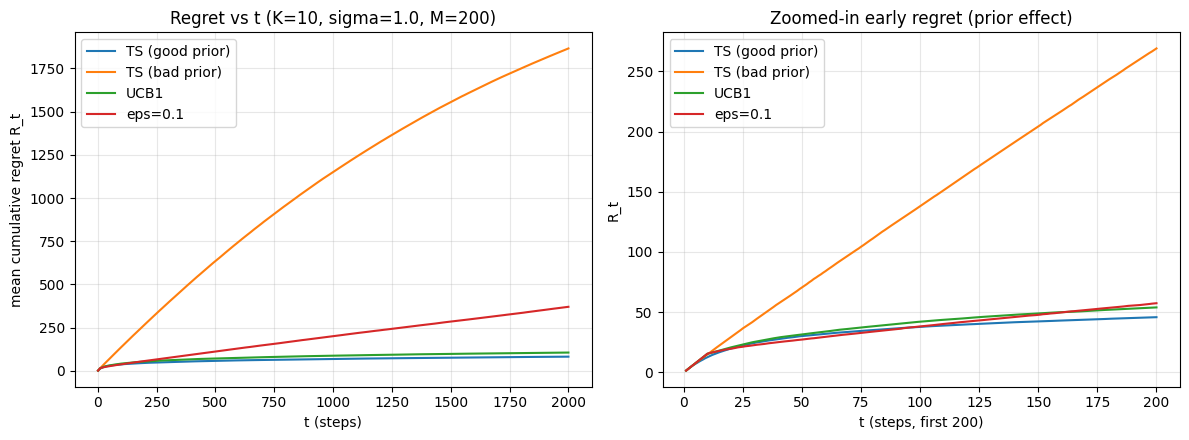

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for name in avg_R:
    ax.plot(np.arange(1, T + 1), avg_R[name], label=name)
ax.set_xlabel("t (steps)"); ax.set_ylabel("mean cumulative regret R_t")
ax.set_title(f"Regret vs t (K={K}, sigma={sigma}, M={M})")
ax.grid(True, alpha=0.3); ax.legend()

ax = axes[1]
for name in avg_R:
    ax.plot(np.arange(1, 201), avg_R[name][:200], label=name)
ax.set_xlabel("t (steps, first 200)"); ax.set_ylabel("R_t")
ax.set_title("Zoomed-in early regret (prior effect)")
ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig("/tmp/nb3_fig.png", dpi=100)
plt.show()


## 4. 결과 해석

- **TS (good prior)** 은 대부분의 인스턴스에서 UCB1 을 근소하게 능가한다.
  베이지안 관점에서 posterior 표본이 곧 확률적 탐색 강도이며, 데이터가 쌓일수록 posterior 가 좁아져
  자동으로 활용 우위로 이동한다. 사전 정보(진짜 $\mu \sim \mathcal N(0,1)$)와 일치하는 사전분포가
  이 자동조율의 출발점이다.
- **TS (bad prior)** 는 사전평균 5, 표준편차 0.1 로 매우 좁고 낙관적이라 초기에는 실제 데이터가 사전을
  극복하기 어렵다. Zoom 뷰에서 볼 수 있듯 **초기 200 스텝의 리그렛**이 다른 정책들보다 뚜렷히 높다.
  그러나 데이터가 충분히 쌓이면 사후분포가 결국 데이터에 지배되어 리그렛 곡선이 완만해진다.
- **UCB1** 과의 비교는 근접하지만, UCB1 의 신뢰상한 폭이 항상 결정적이라 최악의 경우엔 다소 보수적.
  TS 는 확률적 표본이라 잘 지정된 사전에서 더 공격적인 활용이 가능하다.
- **eps=0.1** 은 여전히 리그렛의 상수 기울기가 지배해 큰 $T$ 에서는 뒤처진다.

### 결론
> **Thompson Sampling = "사후분포에서 뽑아 최댓값 선택"** — posterior 표본 자체가 자연스러운 탐색-활용
> 절충을 제공한다. **사전이 잘 지정되면 UCB1 을 능가**하고, 잘못 지정되면 초기 리그렛 대가를 치른다.

### 다음 문제 / 다음 단원으로의 연결
§15.1 은 단순 정지 밴딧을 다뤘다. 다음 절 §15.2 는 **문맥적 밴딧(contextual bandit)** —
각 스텝에서 특징 벡터 $x_t$ 가 주어질 때 LinUCB / LinTS 로 확장한다. 이는 온라인 학습(Ch 14)과
자연스럽게 결합되어 실전 추천·광고 시스템의 기본 알고리즘이 된다.
